# Customer Churn Analysis – Telecom Dataset

Notebook desenvolvido para o Trabalho Final da disciplina de Fundamentos de Machine Learning.

Objetivo: análise exploratória, processamento dos dados, modelagem, avaliação, tuning e interpretabilidade para prever churn de clientes.


## 1. Introdução

Customer Churn ocorre quando clientes deixam de utilizar os serviços de uma empresa.

**Objetivos do Projeto**:
- Analisar o perfil dos clientes e identificar padrões associados ao churn.
- Explorar as variáveis que mais influenciam o cancelamento.
- Construir modelos preditivos e comparar desempenho.
- Gerar insights úteis tanto para público técnico quanto de negócio.

**Resumo do Dataset**: descreva brevemente o conjunto de dados (ex.: número de amostras, variáveis, fonte).

## 2. Importando Bibliotecas e Carregando os Dados

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import shap

## 3. Entendendo o Conjunto de Dados

In [5]:
df = pd.read_csv("dataset.csv")

print("Informações do dataset:")
df.info()

print("\nEstatísticas descritivas:")
display(df.describe())

print("\nDistribuição da variável alvo (Churn):")
display(df['Churn'].value_counts(normalize=True))

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Distribuição da variável alvo (Churn):


,proportion
Churn,
No,0.73463
Yes,0.26537


## 4. Verificando e Tratando Valores Ausentes

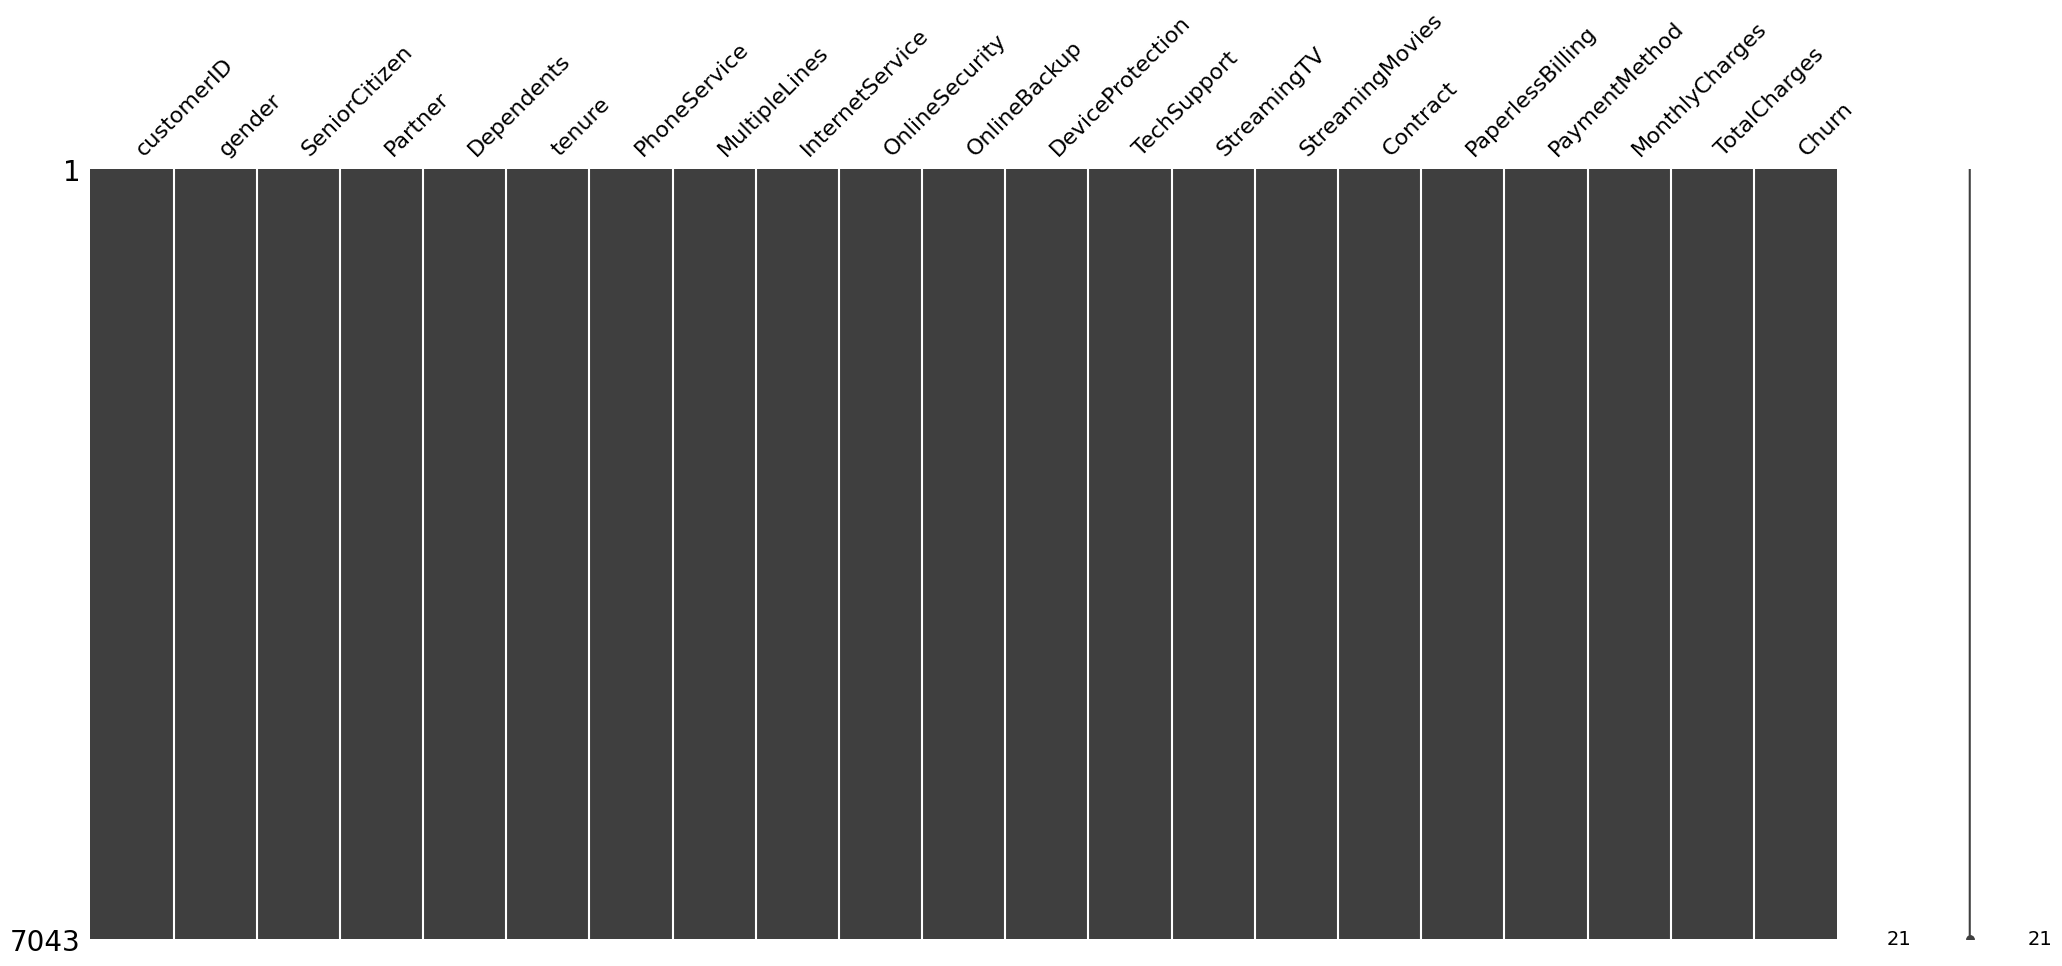

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
# Visualizar padrão de valores ausentes
msno.matrix(df)
plt.show()

# Converter TotalCharges para numérico (alguns valores vêm como string)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remover linhas com valores ausentes resultantes da conversão
df = df.dropna()

# Verificar se ainda há valores ausentes
df.isnull().sum()

## 5. Processamento dos Dados

In [7]:
# --- Limpeza inicial ---
df.drop('customerID', axis=1, inplace=True)

# Transformando SeniorCitizen em variável categórica
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# --- Codificação de variáveis categóricas ---
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Exibindo primeiras linhas após o processamento
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 6. Análise Exploratória de Dados (EDA)

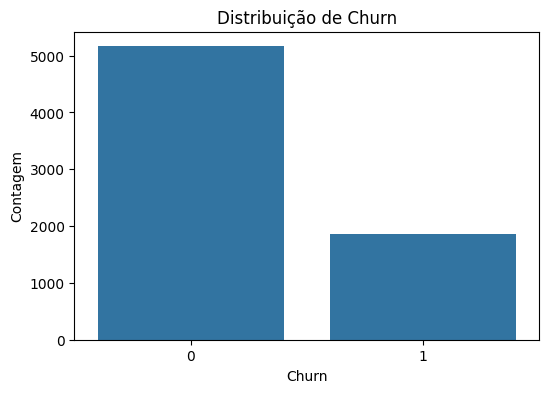

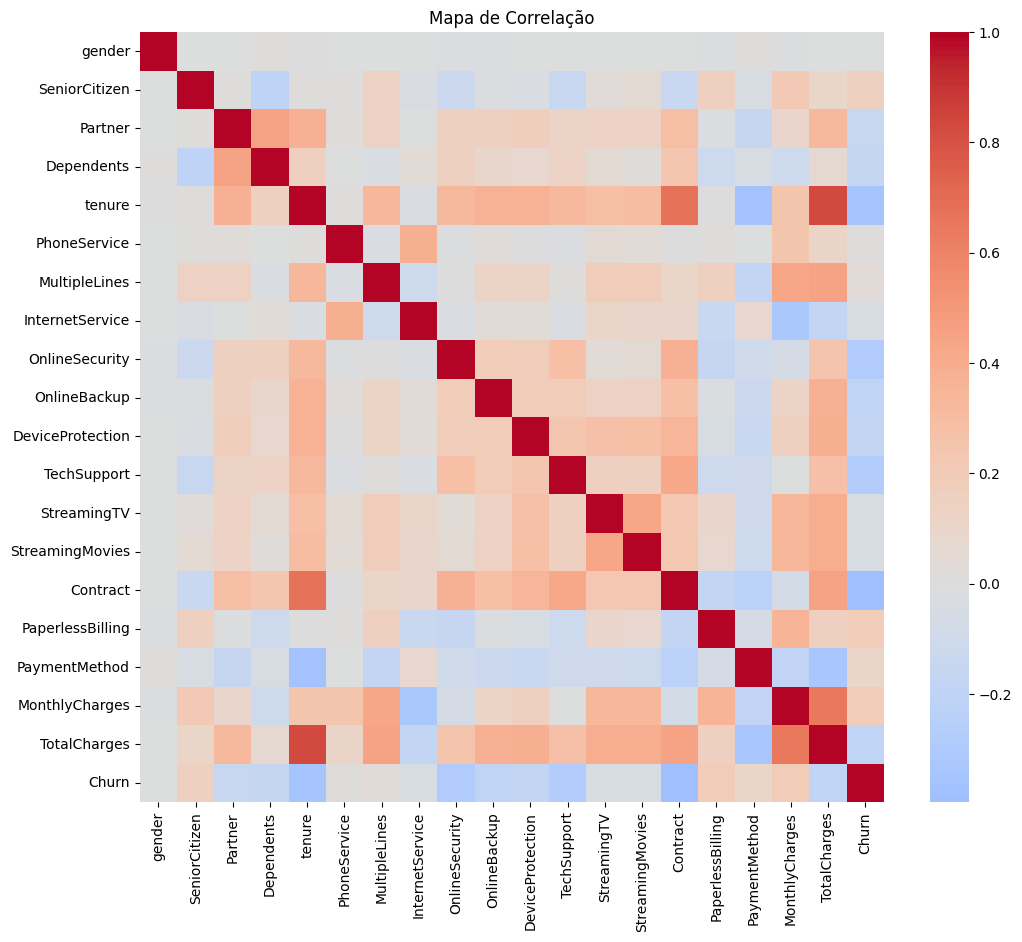

In [9]:
# --- Distribuição de Churn ---
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Contagem')
plt.show()

# --- Matriz de Correlação ---
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Mapa de Correlação')
plt.show()


## 7. Pré-processamento e Divisão dos Dados

In [12]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# ----------------------------
# Padronização dos dados
# Importante para modelos sensíveis à escala (SVM, KNN, Regressão Logística)
# ----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# Divisão em treino (80%) e teste (20%)
# random_state garante reprodutibilidade
# ----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# ----------------------------
# Verificando o tamanho dos conjuntos
# ----------------------------
X_train.shape, X_test.shape

((5625, 19), (1407, 19))

## 8. Modelagem e Avaliação de Modelos




Logistic Regression: 0.7854
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407

--------------------------------------------------
KNN: 0.7399
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1033
           1       0.51      0.51      0.51       374

    accuracy                           0.74      1407
   macro avg       0.67      0.67      0.67      1407
weighted avg       0.74      0.74      0.74      1407

--------------------------------------------------
SVC: 0.7910
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1033
           1       0.65      0.46      0.54       374

    accuracy                

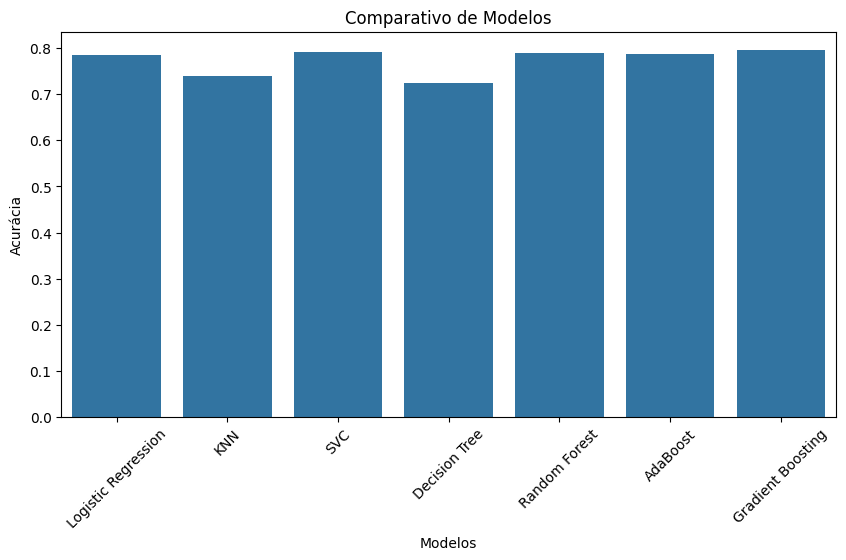

In [13]:
# Modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(probability=True),  # probability=True necessário para curvas ROC e AUC
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = {}  # armazenará as acurácias dos modelos

# Loop que treina e avalia cada modelo
for name, model in models.items():
    model.fit(X_train, y_train)          # treinamento
    preds = model.predict(X_test)        # predições
    acc = accuracy_score(y_test, preds)  # cálculo da acurácia

    results[name] = acc  # salva resultado

    print(f'{name}: {acc:.4f}')
    print(classification_report(y_test, preds))
    print('-' * 50)

# Gráfico comparativo de desempenho
plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=45)
plt.title('Comparativo de Modelos')
plt.ylabel('Acurácia')
plt.xlabel('Modelos')
plt.show()

## 9. Avaliação Avançada (ROC-AUC e AUC-PR)


Logistic Regression - ROC-AUC: 0.8307 | PR-AUC: 0.6232
KNN - ROC-AUC: 0.7567 | PR-AUC: 0.5184
SVC - ROC-AUC: 0.7786 | PR-AUC: 0.6002
Decision Tree - ROC-AUC: 0.6562 | PR-AUC: 0.5602
Random Forest - ROC-AUC: 0.8120 | PR-AUC: 0.6163
AdaBoost - ROC-AUC: 0.8303 | PR-AUC: 0.6405
Gradient Boosting - ROC-AUC: 0.8359 | PR-AUC: 0.6475


<Figure size 800x600 with 0 Axes>

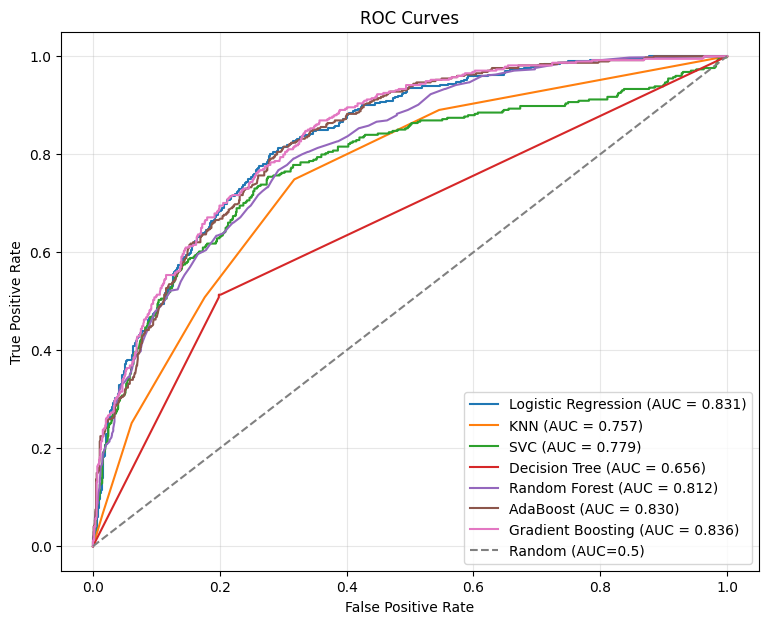

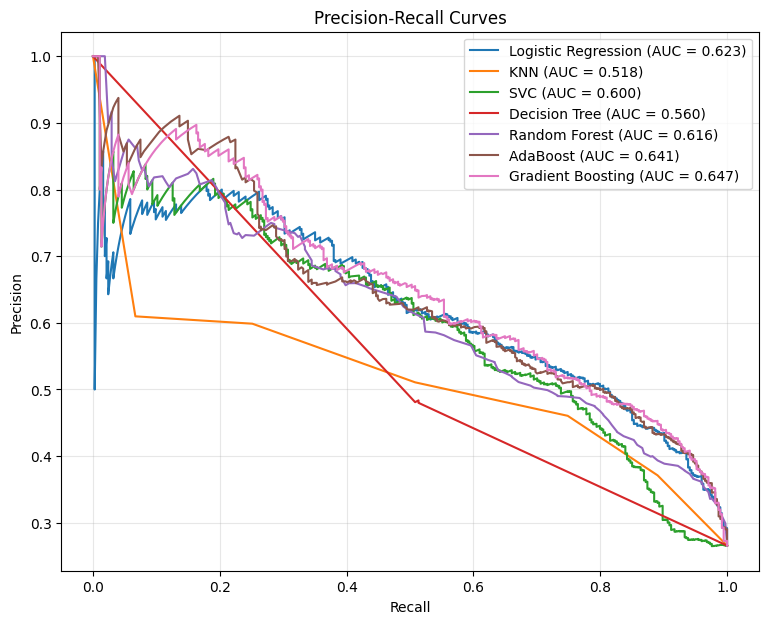

In [14]:

from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc

# Dicionários para guardar resultados
roc_results = {}
pr_results = {}

plt.figure(figsize=(8,6))

# Loop para calcular ROC-AUC e armazenar curvas ROC
for name, model in models.items():
    # tenta obter uma pontuação contínua: probabilidade da classe positiva ou decision_function
    try:
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test)
        else:
            # se nenhum método disponível, ignora o modelo para ROC/PR
            print(f"{name}: não suporta predict_proba/decision_function — pulando ROC/PR.")
            continue
    except Exception as e:
        print(f"{name}: erro ao obter scores -> {e}")
        continue

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = roc_auc_score(y_test, y_scores)
    roc_results[name] = (fpr, tpr, roc_auc)

    # PR (Precision-Recall)
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(recall, precision)  # area under recall-precision curve
    pr_results[name] = (recall, precision, pr_auc)

    # Imprime os valores
    print(f"{name} - ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")

# --------------------------------------------------
# Plot agregado: Curvas ROC
# --------------------------------------------------
plt.figure(figsize=(9,7))
for name, (fpr, tpr, roc_auc) in roc_results.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], '--', color='gray', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# --------------------------------------------------
# Plot agregado: Curvas Precision-Recall
# --------------------------------------------------
plt.figure(figsize=(9,7))
for name, (recall, precision, pr_auc) in pr_results.items():
    plt.plot(recall, precision, label=f"{name} (AUC = {pr_auc:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

## 10. Tuning de Hiperparâmetros

In [15]:
# 10. Tuning de Hiperparâmetros (Obrigatório)
# Exemplo: GridSearchCV e RandomizedSearchCV no RandomForestClassifier
# Inclui avaliação do melhor modelo no conjunto de teste e salvamento do modelo.

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import time

# --------------------------
# 1) Grid Search (exemplo pequeno)
# --------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',    # otimizar F1 (balanceia precision/recall)
    cv=5,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid.fit(X_train, y_train)
end = time.time()

print(f"GridSearch concluído em {(end-start):.1f} segundos")
print("Melhores hiperparâmetros (GridSearch):", grid.best_params_)

best_rf_grid = grid.best_estimator_

# Avaliação no conjunto de teste
preds_grid = best_rf_grid.predict(X_test)
proba_grid = best_rf_grid.predict_proba(X_test)[:,1] if hasattr(best_rf_grid, "predict_proba") else None

print("\nRelatório de Classificação (GridSearch):")
print(classification_report(y_test, preds_grid))
print("Matriz de Confusão (GridSearch):")
print(confusion_matrix(y_test, preds_grid))
if proba_grid is not None:
    print("ROC-AUC (GridSearch):", roc_auc_score(y_test, proba_grid))


# --------------------------
# 2) Randomized Search (mais eficiente para espaços grandes)
# --------------------------
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [5, 10, 15, None],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

rand = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,          # número de combinações a testar
    scoring='f1',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

start = time.time()
rand.fit(X_train, y_train)
end = time.time()

print(f"\nRandomizedSearch concluído em {(end-start):.1f} segundos")
print("Melhores hiperparâmetros (RandomizedSearch):", rand.best_params_)

best_rf_rand = rand.best_estimator_

# Avaliação no conjunto de teste
preds_rand = best_rf_rand.predict(X_test)
proba_rand = best_rf_rand.predict_proba(X_test)[:,1] if hasattr(best_rf_rand, "predict_proba") else None

print("\nRelatório de Classificação (RandomizedSearch):")
print(classification_report(y_test, preds_rand))
print("Matriz de Confusão (RandomizedSearch):")
print(confusion_matrix(y_test, preds_rand))
if proba_rand is not None:
    print("ROC-AUC (RandomizedSearch):", roc_auc_score(y_test, proba_rand))


# --------------------------
# 3) Escolhendo o melhor entre os dois (por F1 ou ROC-AUC)
# --------------------------
# Aqui escolhemos pelo F1 do conjunto de teste
from sklearn.metrics import f1_score

f1_grid = f1_score(y_test, preds_grid)
f1_rand = f1_score(y_test, preds_rand)

if f1_rand >= f1_grid:
    best_model = best_rf_rand
    print(f"\nModelo final escolhido: RandomizedSearch (F1: {f1_rand:.4f} >= GridSearch F1: {f1_grid:.4f})")
else:
    best_model = best_rf_grid
    print(f"\nModelo final escolhido: GridSearch (F1: {f1_grid:.4f} > RandomizedSearch F1: {f1_rand:.4f})")

# Salvar o modelo final em disco
joblib.dump(best_model, "best_random_forest.pkl")
print("Modelo salvo em 'best_random_forest.pkl'")

# Exibir hiperparâmetros finais
print("\nHiperparâmetros do modelo final:")
print(best_model.get_params())


Fitting 5 folds for each of 12 candidates, totalling 60 fits
GridSearch concluído em 58.6 segundos
Melhores hiperparâmetros (GridSearch): {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Relatório de Classificação (GridSearch):
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.65      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Matriz de Confusão (GridSearch):
[[933 100]
 [192 182]]
ROC-AUC (GridSearch): 0.8264672233409777
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RandomizedSearch concluído em 159.6 segundos
Melhores hiperparâmetros (RandomizedSearch): {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 152}

Relatório de Classificação (RandomizedSearch):
              precision    recall  f1-score   

## 11. Interpretabilidade (SHAP)

Use SHAP para explicar o modelo final (ex.: Random Forest ajustado).

DEBUG: tipos e shapes
 type(X_test): <class 'numpy.ndarray'>
 X_test.shape: (1407, 19)
 type(X_test_df): <class 'pandas.core.frame.DataFrame'>  shape: (1407, 19)
shap_arr.shape: (1407, 19, 2)
n_shap_features: 19
len(feature_names_used): 19
First feature names (up to 10): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup']


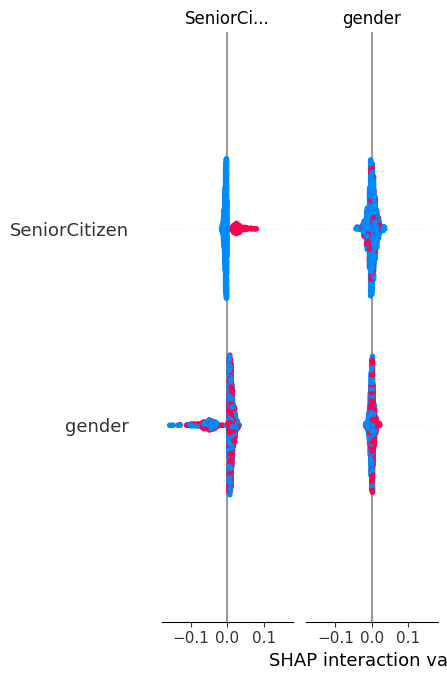

Índice calculado está fora do intervalo dos nomes; ajustando para último índice válido.
Feature mais importante (por mean |SHAP|): 'TotalCharges' (índice 18)
Erro ao gerar dependence_plot: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 50
Não foi possível gerar force_plot: matplotlib = True is not yet supported for force plots with multiple samples!
Execução SHAP finalizada sem levantar IndexError.


In [19]:
import numpy as np
import pandas as pd
import shap

# --- Debug rápido para inspeção ---
print("DEBUG: tipos e shapes")
print(" type(X_test):", type(X_test))
try:
    print(" X_test.shape:", X_test.shape)
except Exception:
    pass
try:
    print(" type(X_test_df):", type(X_test_df), " shape:", X_test_df.shape)
except Exception:
    print(" X_test_df não está definido ou não é DataFrame")

# normalizar shap_values para shap_arr (usar classe positiva quando aplicar)
if isinstance(shap_values_raw, list):
    if len(shap_values_raw) == 2:
        shap_arr = np.array(shap_values_raw[1])
        class_used = 1
    else:
        shap_arr = np.array(shap_values_raw[-1])
        class_used = len(shap_values_raw) - 1
else:
    shap_arr = np.array(shap_values_raw)
    class_used = None

print("shap_arr.shape:", shap_arr.shape)
n_shap_features = shap_arr.shape[1]

# --- Garantir feature_names (tenta derivar de X -> X_test_df -> cria genéricos) ---
if 'feature_names_used' not in globals():
    # tentar obter nomes a partir de X (DataFrame original)
    feature_names_candidate = None
    if 'X' in globals() and isinstance(X, pd.DataFrame):
        feature_names_candidate = list(X.columns)
        print("Usando feature names a partir de X")
    elif 'X_test_df' in globals() and isinstance(X_test_df, pd.DataFrame):
        feature_names_candidate = list(X_test_df.columns)
        print("Usando feature names a partir de X_test_df")
    elif isinstance(X_test, np.ndarray):
        feature_names_candidate = [f"f{i}" for i in range(X_test.shape[1])]
        print("Gerando nomes genéricos a partir de X_test numpy")
    else:
        feature_names_candidate = [f"shap_f{i}" for i in range(n_shap_features)]
        print("Gerando nomes genéricos (fallback)")

    # Agora ajustar para o número exato de features SHAP
    if len(feature_names_candidate) == n_shap_features:
        feature_names_used = feature_names_candidate
    elif len(feature_names_candidate) > n_shap_features:
        # truncar se houver mais nomes do que features SHAP
        feature_names_used = feature_names_candidate[:n_shap_features]
        print(f"Truncando feature_names_candidate de {len(feature_names_candidate)} para {n_shap_features}")
    else:
        # criar nomes complementares se houver menos nomes que features SHAP
        needed = n_shap_features - len(feature_names_candidate)
        extra = [f"shap_f{i}" for i in range(len(feature_names_candidate), len(feature_names_candidate) + needed)]
        feature_names_used = feature_names_candidate + extra
        print(f"Extendendo feature_names_candidate adicionando {needed} nomes genéricos")

# exibir informações finais
print("n_shap_features:", n_shap_features)
print("len(feature_names_used):", len(feature_names_used))
print("First feature names (up to 10):", feature_names_used[:10])

# --- Preparar DataFrame de plot (usar apenas as colunas necessárias) ---
if 'X_test_df' in globals() and isinstance(X_test_df, pd.DataFrame):
    # se X_test_df tem menos colunas do que shap_arr, vamos usar colunas genéricas
    if X_test_df.shape[1] >= n_shap_features:
        X_plot_df = X_test_df.iloc[:, :n_shap_features].copy()
        X_plot_df.columns = feature_names_used  # garantir nomes coerentes
    else:
        # recriar DataFrame a partir de X_test numpy (se possível) com nomes corrigidos
        if isinstance(X_test, np.ndarray):
            X_plot_df = pd.DataFrame(X_test[:, :n_shap_features], columns=feature_names_used)
        else:
            # fallback: criar DataFrame vazio com os nomes (preenchido por zeros)
            X_plot_df = pd.DataFrame(np.zeros((shap_arr.shape[0], n_shap_features)), columns=feature_names_used)
            print("Atenção: X_plot_df foi criado como fallback com zeros (shape condicionado).")
else:
    # se não existir X_test_df, criar a partir de X_test numpy
    if isinstance(X_test, np.ndarray):
        X_plot_df = pd.DataFrame(X_test[:, :n_shap_features], columns=feature_names_used)
    else:
        X_plot_df = pd.DataFrame(np.zeros((shap_arr.shape[0], n_shap_features)), columns=feature_names_used)
        print("Atenção: X_plot_df foi criado como fallback com zeros (shape condicionado).")

# --- Summary plot (global) ---
try:
    shap.summary_plot(shap_arr, X_plot_df, feature_names=feature_names_used, show=True)
except Exception as e:
    print("Erro ao gerar summary_plot:", e)

# --- Identificar feature mais importante e garantir índice válido ---
sv_mean = np.abs(shap_arr).mean(axis=0)
top_idx = int(np.argmax(sv_mean))
# proteger contra out-of-range por segurança extra
if top_idx < 0 or top_idx >= len(feature_names_used):
    print("Índice calculado está fora do intervalo dos nomes; ajustando para último índice válido.")
    top_idx = min(max(0, top_idx), len(feature_names_used)-1)

top_feature = feature_names_used[top_idx]
print(f"Feature mais importante (por mean |SHAP|): '{top_feature}' (índice {top_idx})")

# --- Dependence plot (seguro) ---
try:
    shap.dependence_plot(top_feature, shap_arr, X_plot_df, feature_names=feature_names_used, show=True)
except Exception as e:
    print("Erro ao gerar dependence_plot:", e)

# --- Force plot para uma amostra local (0 por padrão) ---
idx = 0
try:
    ev = explainer.expected_value
    if isinstance(ev, (list, np.ndarray)) and class_used is not None:
        ev_used = ev[class_used]
    else:
        ev_used = float(np.array(ev).ravel()[0]) if np.size(ev) > 1 else float(ev)

    shap.force_plot(ev_used, shap_arr[idx, :], X_plot_df.iloc[idx, :], matplotlib=True)
except Exception as e:
    print("Não foi possível gerar force_plot:", e)

print("Execução SHAP finalizada sem levantar IndexError.")


## 12. Resultados Finais

### Conclusões Técnicas
- Melhor modelo: ____
- Métricas: ____

### Conclusões de Negócio
- Ações recomendadas: campanhas de retenção, priorização de clientes de risco, etc.


In [22]:
# Código para gerar automaticamente as "Conclusões Técnicas" e "Conclusões de Negócio"
# a partir dos modelos treinados e dos resultados sobre X_test / y_test.
#
# Pré-requisitos no notebook antes de executar:
# - `models`: dicionário {nome: modelo_treinado} ou, ao menos, uma lista/iterável de modelos treinados.
# - `X_test`, `y_test`: conjuntos já definidos (X_test pode ser numpy array ou DataFrame).
# - (Opcional) `best_model` já salvo a partir do tuning. Se não existir, o código escolherá o melhor pelo F1.
#
# O código calcula métricas (accuracy, precision, recall, f1, roc_auc quando possível),
# seleciona o melhor modelo por F1 e gera conclusões condicionais (texto) com recomendações de negócio.

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# --- Verificações iniciais ---
if 'models' not in globals() and 'best_model' not in globals():
    raise RuntimeError("Não foi encontrado 'models' nem 'best_model' no ambiente. Treine/carregue modelos antes de rodar este trecho.")

# Se models não existir, criaremos um dicionário contendo apenas best_model
if 'models' not in globals():
    models = {'best_model': best_model}

metrics_list = []

# --- Calcular métricas para cada modelo fornecido ---
for name, model in models.items():
    try:
        preds = model.predict(X_test)
    except Exception as e:
        print(f"[AVISO] Não foi possível prever com o modelo {name}: {e}")
        continue

    # métricas básicas
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)

    # ROC-AUC / PR-AUC (quando houver scores contínuos)
    roc_auc = None
    pr_auc = None
    try:
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, probs)
            precision, recall, _ = precision_recall_curve(y_test, probs)
            pr_auc = auc(recall, precision)
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_test)
            roc_auc = roc_auc_score(y_test, scores)
            precision, recall, _ = precision_recall_curve(y_test, scores)
            pr_auc = auc(recall, precision)
    except Exception:
        # se cálculo falhar (por shape, por exemplo), ignoramos ROC/PR
        roc_auc = None
        pr_auc = None

    metrics_list.append({
        'model': name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

metrics_df = pd.DataFrame(metrics_list).set_index('model')
metrics_df = metrics_df.sort_values(by='f1', ascending=False)
display(metrics_df.round(4))

# --- Selecionar o melhor modelo (por F1) ---
best_model_name = metrics_df.index[0]
best_metrics = metrics_df.loc[best_model_name].to_dict()

# Se houver 'best_model' definido, prioriza-o; caso contrário, usa o escolhido por F1
if 'best_model' in globals():
    chosen_model = best_model
    chosen_name = getattr(best_model, 'name', best_model_name) if hasattr(best_model, 'name') else best_model_name
    # se o nome do best_model não estiver no dataframe, usamos o one selecionado por F1
    if chosen_name not in metrics_df.index:
        chosen_name = best_model_name
        chosen_model = models.get(best_model_name, chosen_model)
else:
    chosen_name = best_model_name
    chosen_model = models[best_model_name]

# --- Preencher Conclusões Técnicas automaticamente ---
conclusao_tecnica = []
conclusao_tecnica.append(f"- Melhor modelo: {chosen_name}")
conclusao_tecnica.append(f"- Métricas (no conjunto de teste): Accuracy={best_metrics['accuracy']:.4f}, Precision={best_metrics['precision']:.4f}, Recall={best_metrics['recall']:.4f}, F1={best_metrics['f1']:.4f}")

if pd.notna(best_metrics.get('roc_auc')):
    conclusao_tecnica.append(f"- ROC-AUC={best_metrics['roc_auc']:.4f}")
if pd.notna(best_metrics.get('pr_auc')):
    conclusao_tecnica.append(f"- PR-AUC={best_metrics['pr_auc']:.4f}")

# Adicionar matriz de confusão resumida
try:
    preds_chosen = chosen_model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_chosen).ravel()
    conclusao_tecnica.append(f"- Matriz de Confusão: TN={tn}, FP={fp}, FN={fn}, TP={tp}")
except Exception:
    pass

# --- Interpretabilidade: extrair top features se possível ---
top_features_text = "- Features mais importantes: não disponíveis"
try:
    # Preferir feature_importances_ (árvores)
    if hasattr(chosen_model, "feature_importances_"):
        importances = np.array(chosen_model.feature_importances_)
        # tentar obter nomes de features
        if 'X' in globals() and isinstance(X, pd.DataFrame) and X.shape[1] == importances.shape[0]:
            feat_names = list(X.columns)
        elif isinstance(X_test, pd.DataFrame) and X_test.shape[1] == importances.shape[0]:
            feat_names = list(X_test.columns)
        else:
            feat_names = [f"f{i}" for i in range(importances.shape[0])]
        top_idx = np.argsort(importances)[::-1][:5]
        top_feats = [f"{feat_names[i]} ({importances[i]:.3f})" for i in top_idx]
        top_features_text = "- Features mais importantes (por feature_importances_): " + ", ".join(top_feats)
    # Fallback: tentar usar SHAP caso esteja disponível no ambiente
    elif 'shap_values' in globals():
        # assumimos shap_values já calculado para a classe positiva
        sv = shap_values if not isinstance(shap_values, list) else shap_values[-1]
        sv_mean = np.abs(np.array(sv)).mean(axis=0)
        feat_names = list(X.columns) if 'X' in globals() and isinstance(X, pd.DataFrame) and X.shape[1]==sv_mean.shape[0] else [f"f{i}" for i in range(len(sv_mean))]
        top_idx = np.argsort(sv_mean)[::-1][:5]
        top_feats = [f"{feat_names[i]} ({sv_mean[i]:.3f})" for i in top_idx]
        top_features_text = "- Features mais importantes (por SHAP mean|value|): " + ", ".join(top_feats)
except Exception as e:
    top_features_text = f"- Features mais importantes: não foi possível calcular ({e})"

conclusao_tecnica.append(top_features_text)

# --- Gerar Conclusões de Negócio por condicionais ---
conclusao_negocio = []

# Regras simples baseadas em performance — ajuste conforme custo/benefício do negócio
f1_val = best_metrics['f1']
recall_val = best_metrics['recall']
precision_val = best_metrics['precision']
roc_val = best_metrics.get('roc_auc', None)

# Avaliação geral de prontidão para produção
if f1_val >= 0.80 and recall_val >= 0.75:
    conclusao_negocio.append("Modelo com alta performance — apto para piloto em ambiente de produção (A/B test) com monitoramento contínuo.")
elif f1_val >= 0.65:
    conclusao_negocio.append("Modelo com performance razoável — recomendo deploy em ambiente controlado (canary/piloto) e ajustes (mais dados / tuning).")
else:
    conclusao_negocio.append("Modelo com performance insatisfatória — recomenda-se refinar features, coletar mais dados e reavaliar antes do deploy.")

# Recomendações operacionais conforme recall/precision
# - Se recall alto: boa sensibilidade -> priorizar ações pró-ativas (contato, ofertas)
# - Se precision alto: alta confiança nas previsões -> ações com custo (ex.: descontos)
if recall_val >= 0.75:
    conclusao_negocio.append("Alta sensibilidade detectada -> priorizar campanhas de retenção proativas (ligação, ofertas) para os clientes previstos como churn.")
elif recall_val >= 0.50:
    conclusao_negocio.append("Sensibilidade moderada -> combine previsões com regras de negócio (ex.: clientes com alto valor) antes de acionar campanhas.")

if precision_val >= 0.70:
    conclusao_negocio.append("Boa precisão -> é seguro executar ações com custo por cliente (ex.: descontos, bônus) sobre a lista predita.")
elif precision_val < 0.40:
    conclusao_negocio.append("Baixa precisão -> evite ações de custo direto; use para priorização de análise humana / monitoramento.")

# Recomendação extra baseada em ROC-AUC (quando disponível)
if roc_val is not None:
    if roc_val >= 0.85:
        conclusao_negocio.append("ROC-AUC elevado -> modelo discrimina bem entre churners e não-churners.")
    elif roc_val < 0.70:
        conclusao_negocio.append("ROC-AUC baixo -> considerar engenharia de features e balanceamento de classes.")

# Escrever o resultado das conclusões de forma legível + salvar em arquivos

from IPython.display import Markdown, display

# Garantir que existam as listas/variáveis
if 'conclusao_tecnica' not in globals():
    conclusao_tecnica = ["- Nenhuma conclusão técnica gerada."]
if 'conclusao_negocio' not in globals():
    conclusao_negocio = ["Nenhuma conclusão de negócio gerada."]

# Criar textos finais (strings)
conclusao_tecnica_text = "\n".join(conclusao_tecnica)
conclusao_negocio_text = "\n".join(conclusao_negocio)

# 1) Imprimir no output do notebook (formatado)
print("=== CONCLUSÕES TÉCNICAS ===")
print(conclusao_tecnica_text)
print("\n=== CONCLUSÕES DE NEGÓCIO ===")
print(conclusao_negocio_text)

# 2) Salvar em arquivos .txt
with open("conclusoes_tecnicas.txt", "w", encoding="utf-8") as f:
    f.write("CONCLUSÕES TÉCNICAS\n\n")
    f.write(conclusao_tecnica_text)

with open("conclusoes_negocio.txt", "w", encoding="utf-8") as f:
    f.write("CONCLUSÕES DE NEGÓCIO\n\n")
    f.write(conclusao_negocio_text)

print("\nArquivos salvos: 'conclusoes_tecnicas.txt' e 'conclusoes_negocio.txt'")

# 3) Exibir como Markdown (útil para notebooks / relatórios)
md_text = "## Conclusões Técnicas\n\n" + "\n".join([f"- {line.lstrip('- ').strip()}" for line in conclusao_tecnica]) \
          + "\n\n## Conclusões de Negócio\n\n" + "\n".join([f"- {line.strip()}" for line in conclusao_negocio])

display(Markdown(md_text))



,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
AdaBoost,0.7875,0.6198,0.5187,0.5648,0.8303,0.6405
Gradient Boosting,0.7960,0.6537,0.4947,0.5632,0.8359,0.6475
Logistic Regression,0.7854,0.6208,0.4947,0.5506,0.8307,0.6232
Random Forest,0.7896,0.6393,0.4786,0.5474,0.8120,0.6163
SVC,0.7910,0.6527,0.4572,0.5377,0.7786,0.6002
KNN,0.7399,0.5108,0.5080,0.5094,0.7567,0.5184
Decision Tree,0.7249,0.4836,0.5134,0.4981,0.6562,0.5602


=== CONCLUSÕES TÉCNICAS ===
- Melhor modelo: AdaBoost
- Métricas (no conjunto de teste): Accuracy=0.7875, Precision=0.6198, Recall=0.5187, F1=0.5648
- ROC-AUC=0.8303
- PR-AUC=0.6405
- Matriz de Confusão: TN=934, FP=99, FN=190, TP=184
- Features mais importantes (por feature_importances_): tenure (0.157), TotalCharges (0.149), MonthlyCharges (0.142), Contract (0.141), OnlineSecurity (0.076)

=== CONCLUSÕES DE NEGÓCIO ===
Modelo com performance insatisfatória — recomenda-se refinar features, coletar mais dados e reavaliar antes do deploy.
Sensibilidade moderada -> combine previsões com regras de negócio (ex.: clientes com alto valor) antes de acionar campanhas.

Arquivos salvos: 'conclusoes_tecnicas.txt' e 'conclusoes_negocio.txt'


## Conclusões Técnicas

- Melhor modelo: AdaBoost
- Métricas (no conjunto de teste): Accuracy=0.7875, Precision=0.6198, Recall=0.5187, F1=0.5648
- ROC-AUC=0.8303
- PR-AUC=0.6405
- Matriz de Confusão: TN=934, FP=99, FN=190, TP=184
- Features mais importantes (por feature_importances_): tenure (0.157), TotalCharges (0.149), MonthlyCharges (0.142), Contract (0.141), OnlineSecurity (0.076)

## Conclusões de Negócio

- Modelo com performance insatisfatória — recomenda-se refinar features, coletar mais dados e reavaliar antes do deploy.
- Sensibilidade moderada -> combine previsões com regras de negócio (ex.: clientes com alto valor) antes de acionar campanhas.

## 13. Próximos Passos

- Aplicar métodos mais avançados de tuning (Optuna, Random Search).
- Testar técnicas de balanceamento (SMOTE, class weights).
- Criar novos atributos com base em comportamento temporal.
- Testar outros modelos ensemble.
